# THREAT-SCOPE Bioinformatics Pipeline

This notebook walks through:
1. Loading master.csv
2. Splitting data
3. Loading DNA (.fasta) files
4. Extracting features (GC content, length)
5. Visualizing results


In [1]:
# Install dependencies
!pip install pandas scikit-learn biopython seaborn matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 46.8 MB/s eta 0:00:00


In [7]:
# STEP 1: Load master.csv
import pandas as pd

df = pd.read_csv('master.csv')
df

,id,name,mode,label
0,1,cholera_1,water,danger
1,2,Ecoli_1,water,danger
2,3,Ecoli_2,water,danger
3,4,giardia_1,water,danger
4,5,hepatitusAvirus_1,water,danger
5,6,salmonella_1,water,danger
6,7,botulism,food,danger
7,8,campylobacter_1,food,danger
8,9,listeria_1,food,danger
9,10,salmonella_1,food,danger


In [3]:
# STEP 2: Split data
from sklearn.model_selection import train_test_split

train_df, temp_df = train_test_split(df, test_size=0.3, random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42)

train_df.to_csv('train.csv', index=False)
val_df.to_csv('validation.csv', index=False)
test_df.to_csv('test.csv', index=False)

print(len(train_df), len(val_df), len(test_df))

14 3 3


In [4]:
# STEP 3: Load DNA files
from Bio import SeqIO

files = [
    'cholera_1.fasta',
    'Ecoli_1.fasta',
    'Ecoli_2.fasta',
    'giardia_1.fasta',
    'hepatitusAvirus_1.fasta',
    'salmonella_1.fasta',
    'botulism.fasta',
    'campylobacter_1.fasta',
    'listeria_1.fasta',
    'pseudomonas_1.fasta',
    'staphylococcus_1.fasta',
    'streptococcus_1.fasta',
    'tetanus_1.fasta',
    'ebola_1.fasta',
    'influenza_1.fasta',
    'Bifidobacterium_longum_1.fasta',
    'Lactobacillus_acidophilus_1.fasta',
    'Lactococcus_lactis_1.fasta',
    'Streptococcus_thermophilus_1.fasta'
]

In [8]:
# STEP 4: Feature extraction
def gc_content(seq):
    seq = str(seq)
    return (seq.count('G') + seq.count('C')) / len(seq)

data = []

for file in files:
    for record in SeqIO.parse(file, 'fasta'):
        seq = record.seq
        data.append([
            file,
            gc_content(seq),
            len(seq)
        ])

features_df = pd.DataFrame(data, columns=['file', 'gc_content', 'length'])
features_df

,file,gc_content,length
0,cholera_1.fasta,0.477229,2948589
1,cholera_1.fasta,0.469186,1140710
2,cholera_1.fasta,0.412253,49113
3,Ecoli_1.fasta,0.507907,4641652
4,Ecoli_2.fasta,0.505370,5498578
...,...,...,...
64,Lactobacillus_acidophilus_1.fasta,0.347183,1978847
65,Lactococcus_lactis_1.fasta,0.350077,2579381
66,Lactococcus_lactis_1.fasta,0.336935,59700
67,Streptococcus_thermophilus_1.fasta,0.391338,1788289


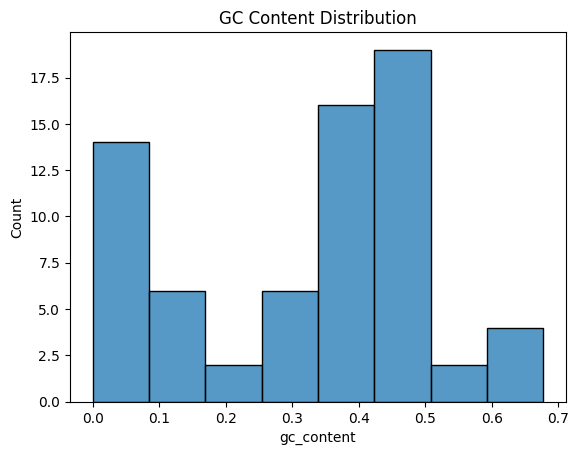

In [9]:
# STEP 5: Plot
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(features_df['gc_content'])
plt.title('GC Content Distribution')
plt.show()